# Exploratory Data Analysis for delay prediction in commercial flights

In [44]:
import os

CHECKPOINT = './data/df_engineered.parquet'

if os.path.exists(CHECKPOINT):
    df = pd.read_parquet(CHECKPOINT)
    print(f"Loaded checkpoint: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
else:
    print("No checkpoint found — run full notebook")

No checkpoint found — run full notebook


In [45]:
import pandas as pd
import numpy as np

def load_data(file_path):
    """
    Load data from a CSV file into a pandas DataFrame.

    Parameters:
    file_path (str): The path to the CSV file.

    Returns:
    pd.DataFrame: A DataFrame containing the loaded data.
    """
    try:
        data = pd.read_csv(file_path)
        return data
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

FILE_PATH = '../data/flight_data_2024.csv'

df = load_data(FILE_PATH)

df.head()

/var/folders/j6/09f5n__n4f5fhrjb290ynm140000gn/T/ipykernel_72625/191219130.py:15: DtypeWarning: Columns (0: cancellation_code) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path)


,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,dest,dest_city_name,dest_state_nm,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,DTW,"Detroit, MI",Michigan,1252,1247.0,-5.0,31.0,1318.0,1442.0,7.0,1508,1449.0,-19.0,0,NaN,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,CLE,"Cleveland, OH",Ohio,1015,1001.0,-14.0,20.0,1021.0,1249.0,6.0,1325,1255.0,-30.0,0,NaN,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,RIC,"Richmond, VA",Virginia,1415,1411.0,-4.0,21.0,1432.0,1533.0,8.0,1601,1541.0,-20.0,0,NaN,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,JFK,"New York, NY",New York,1650,1643.0,-7.0,13.0,1656.0,1747.0,12.0,1841,1759.0,-42.0,0,NaN,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,MKE,"Milwaukee, WI",Wisconsin,1015,1010.0,-5.0,21.0,1031.0,1016.0,4.0,1034,1020.0,-14.0,0,NaN,0,79.0,70.0,45.0,237.0,0,0,0,0,0


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7079081 entries, 0 to 7079080
Data columns (total 35 columns):
 #   Column               Dtype  
---  ------               -----  
 0   year                 int64  
 1   month                int64  
 2   day_of_month         int64  
 3   day_of_week          int64  
 4   fl_date              str    
 5   op_unique_carrier    str    
 6   op_carrier_fl_num    float64
 7   origin               str    
 8   origin_city_name     str    
 9   origin_state_nm      str    
 10  dest                 str    
 11  dest_city_name       str    
 12  dest_state_nm        str    
 13  crs_dep_time         int64  
 14  dep_time             float64
 15  dep_delay            float64
 16  taxi_out             float64
 17  wheels_off           float64
 18  wheels_on            float64
 19  taxi_in              float64
 20  crs_arr_time         int64  
 21  arr_time             float64
 22  arr_delay            float64
 23  cancelled            int64  
 24  cancellat

In [47]:
df.isna().sum()

year                         0
month                        0
day_of_month                 0
day_of_week                  0
fl_date                      0
op_unique_carrier            0
op_carrier_fl_num            1
origin                       0
origin_city_name             0
origin_state_nm              0
dest                         0
dest_city_name               0
dest_state_nm                0
crs_dep_time                 0
dep_time                 92659
dep_delay                92970
taxi_out                 95734
wheels_off               95734
wheels_on                97856
taxi_in                  97856
crs_arr_time                 0
arr_time                 97854
arr_delay               113814
cancelled                    0
cancellation_code      6982766
diverted                     0
crs_elapsed_time             1
actual_elapsed_time     113814
air_time                113814
distance                     0
carrier_delay                0
weather_delay                0
nas_dela

In [48]:
print(df.shape)
print(df.nunique())

(7079081, 35)
year                      1
month                    12
day_of_month             31
day_of_week               7
fl_date                 366
op_unique_carrier        15
op_carrier_fl_num      6862
origin                  348
origin_city_name        342
origin_state_nm          52
dest                    348
dest_city_name          342
dest_state_nm            52
crs_dep_time           1363
dep_time               1440
dep_delay              1862
taxi_out                190
wheels_off             1440
wheels_on              1440
taxi_in                 227
crs_arr_time           1429
arr_time               1440
arr_delay              1887
cancelled                 2
cancellation_code         4
diverted                  2
crs_elapsed_time        587
actual_elapsed_time     719
air_time                681
distance               1626
carrier_delay          1632
weather_delay          1116
nas_delay               849
security_delay          195
late_aircraft_delay    1377
dtype:

In [49]:
df.describe()

,year,month,day_of_month,day_of_week,op_carrier_fl_num,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,cancelled,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,7079081.0,7.079081e+06,7.079081e+06,7.079081e+06,7.079080e+06,7.079081e+06,6.986422e+06,6.986111e+06,6.983347e+06,6.983347e+06,6.981225e+06,6.981225e+06,7.079081e+06,6.981227e+06,6.965267e+06,7.079081e+06,7.079081e+06,7.079080e+06,6.965267e+06,6.965267e+06,7.079081e+06,7.079081e+06,7.079081e+06,7.079081e+06,7.079081e+06,7.079081e+06
mean,2024.0,6.584868e+00,1.578445e+01,3.981945e+00,2.504623e+03,1.327300e+03,1.330765e+03,1.267708e+01,1.790445e+01,1.353542e+03,1.458724e+03,8.326030e+00,1.491365e+03,1.461854e+03,7.098245e+00,1.360558e-02,2.471931e-03,1.467665e+02,1.412151e+02,1.149997e+02,8.339062e+02,5.060440e+00,8.752369e-01,2.771828e+00,2.541686e-02,5.929302e+00
std,0.0,3.396806e+00,8.786433e+00,2.012279e+00,1.652253e+03,4.930306e+02,5.094779e+02,5.605997e+01,9.677410e+00,5.120475e+02,5.404328e+02,6.844510e+00,5.194385e+02,5.459962e+02,5.799127e+01,1.158468e-01,4.965703e-02,7.238692e+01,7.230781e+01,7.036955e+01,5.962536e+02,3.572703e+01,1.542974e+01,1.546485e+01,1.422602e+00,3.106135e+01
min,2024.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-9.600000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-1.260000e+02,0.000000e+00,0.000000e+00,-1.600000e+02,1.500000e+01,5.000000e+00,1.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2024.0,4.000000e+00,8.000000e+00,2.000000e+00,1.151000e+03,9.050000e+02,9.080000e+02,-6.000000e+00,1.200000e+01,9.240000e+02,1.041000e+03,5.000000e+00,1.103000e+03,1.044000e+03,-1.500000e+01,0.000000e+00,0.000000e+00,9.300000e+01,8.800000e+01,6.300000e+01,3.990000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2024.0,7.000000e+00,1.600000e+01,4.000000e+00,2.227000e+03,1.320000e+03,1.325000e+03,-2.000000e+00,1.500000e+01,1.338000e+03,1.500000e+03,6.000000e+00,1.517000e+03,1.503000e+03,-6.000000e+00,0.000000e+00,0.000000e+00,1.300000e+02,1.250000e+02,9.800000e+01,6.800000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2024.0,1.000000e+01,2.300000e+01,6.000000e+00,3.717000e+03,1.736000e+03,1.746000e+03,9.000000e+00,2.100000e+01,1.801000e+03,1.915000e+03,1.000000e+01,1.925000e+03,1.919000e+03,9.000000e+00,0.000000e+00,0.000000e+00,1.770000e+02,1.720000e+02,1.450000e+02,1.069000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,2024.0,1.200000e+01,3.100000e+01,7.000000e+00,8.819000e+03,2.400000e+03,2.400000e+03,3.777000e+03,2.140000e+02,2.400000e+03,2.400000e+03,4.440000e+02,2.359000e+03,2.400000e+03,3.803000e+03,1.000000e+00,1.000000e+00,1.326000e+03,7.920000e+02,7.230000e+02,5.095000e+03,3.689000e+03,1.804000e+03,2.700000e+03,1.164000e+03,2.690000e+03


| Column Name | Description |
|---|---|
| year | Year of flight |
| month | Month of flight (1–12) |
| day_of_month | Day of the month |
| day_of_week | Day of week (1=Monday … 7=Sunday) |
| fl_date | Flight date (YYYY-MM-DD) |
| op_unique_carrier | Unique carrier code |
| op_carrier_fl_num | Flight number for reporting airline |
| origin | Origin airport code |
| origin_city_name | Origin city name |
| origin_state_nm | Origin state name |
| dest | Destination airport code |
| dest_city_name | Destination city name |
| dest_state_nm | Destination state name |
| crs_dep_time | Scheduled departure time (local, hhmm) |
| dep_time | Actual departure time (local, hhmm) |
| dep_delay | Departure delay in minutes (negative if early) |
| taxi_out | Taxi out time in minutes |
| wheels_off | Wheels-off time (local, hhmm) |
| wheels_on | Wheels-on time (local, hhmm) |
| taxi_in | Taxi in time in minutes |
| crs_arr_time | Scheduled arrival time (local, hhmm) |
| arr_time | Actual arrival time (local, hhmm) |
| arr_delay | Arrival delay in minutes (negative if early) |
| cancelled | Cancelled flight indicator (0=No, 1=Yes) |
| cancellation_code | Reason for cancellation (if cancelled) |
| diverted | Diverted flight indicator (0=No, 1=Yes) |
| crs_elapsed_time | Scheduled elapsed time in minutes |
| actual_elapsed_time | Actual elapsed time in minutes |
| air_time | Flight time in minutes |
| distance | Distance between origin and destination (miles) |
| carrier_delay | Carrier-related delay in minutes |
| weather_delay | Weather-related delay in minutes |
| nas_delay | National Air System delay in minutes |
| security_delay | Security delay in minutes |
| late_aircraft_delay | Late aircraft delay in minutes |

In [50]:
df['fl_date'] = pd.to_datetime(df['fl_date'])

In [51]:
# Changing to datetime format for easier manipulation and analysis
df['fl_date']

0         2024-01-01
1         2024-01-01
2         2024-01-01
3         2024-01-01
4         2024-01-01
             ...    
7079076   2024-12-31
7079077   2024-12-31
7079078   2024-12-31
7079079   2024-12-31
7079080   2024-12-31
Name: fl_date, Length: 7079081, dtype: datetime64[us]

In [52]:
df['fl_date'].unique

<bound method Series.unique of 0         2024-01-01
1         2024-01-01
2         2024-01-01
3         2024-01-01
4         2024-01-01
             ...    
7079076   2024-12-31
7079077   2024-12-31
7079078   2024-12-31
7079079   2024-12-31
7079080   2024-12-31
Name: fl_date, Length: 7079081, dtype: datetime64[us]>

## Exploratory Data Analysis 1

After converting to datetime format, next we will look at the nulls and see are they delibarate or not.

There are a total of 13 columns that contain null values of varying range out of the 35.

In [53]:
"""
    Null analysis for deparutre and arrivale related columns with cancellatin codes
    in order to see if all flights with missing departure and arrival times are cancelled flights. 
    If this is the case, we can drop these columns as they will not be useful for our analysis.
        
"""

def check_nulls_vs_cancelled(df):
    cancelled = df[df['cancelled'] == 1]
    null_cols = df.columns[df.isna().sum() > 0]
    
    for col in null_cols:
        
        if col is 'cancellation_code':
            break
        total_null = df[col].isna().sum()
        null_and_cancelled = df[df[col].isna() & (df['cancelled'] == 1)].shape[0]
        unexplained = total_null - null_and_cancelled
        print(f"{col:25s} | null: {total_null:6d} | cancelled: {null_and_cancelled:6d} | unexplained: {unexplained:4d}")

check_nulls_vs_cancelled(df)

<>:14: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:14: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
/var/folders/j6/09f5n__n4f5fhrjb290ynm140000gn/T/ipykernel_72625/3923143654.py:14: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if col is 'cancellation_code':


op_carrier_fl_num         | null:      1 | cancelled:      0 | unexplained:    1
dep_time                  | null:  92659 | cancelled:  92659 | unexplained:    0
dep_delay                 | null:  92970 | cancelled:  92970 | unexplained:    0
taxi_out                  | null:  95734 | cancelled:  95734 | unexplained:    0
wheels_off                | null:  95734 | cancelled:  95734 | unexplained:    0
wheels_on                 | null:  97856 | cancelled:  96315 | unexplained: 1541
taxi_in                   | null:  97856 | cancelled:  96315 | unexplained: 1541
arr_time                  | null:  97854 | cancelled:  96315 | unexplained: 1539
arr_delay                 | null: 113814 | cancelled:  96315 | unexplained: 17499
cancellation_code         | null: 6982766 | cancelled:      0 | unexplained: 6982766
crs_elapsed_time          | null:      1 | cancelled:      1 | unexplained:    0
actual_elapsed_time       | null: 113814 | cancelled:  96315 | unexplained: 17499
air_time              

In [54]:
df['cancellation_code'].notna().sum()

np.int64(96315)

## Exploratory Data Analysis 2 - Nulls

- All flights with null deprature columns:
    + dep_time
    + dep_delay
    + taxi_out 
    + wheels_off
are cancelled flights meaning we can drop them

To-Do: check if the unexplained 1541 and 17499 are diverted flights where the arrival and in flight data is missing.

In [55]:
unexplained = df[df['wheels_on'].isna() & (df['cancelled'] != 1)]
print(unexplained['diverted'].value_counts())

diverted
1    1541
Name: count, dtype: int64


In [56]:
unexplained_arr = df[df['arr_delay'].isna() & (df['cancelled'] != 1) & (df['diverted'] != 1)]
print(f"Count: {len(unexplained_arr)}")
print(unexplained_arr[['dep_time', 'dep_delay', 'arr_time', 'wheels_on']].isna().sum())
print(unexplained_arr[['dep_time', 'dep_delay', 'arr_time']].head(10))

Count: 0
dep_time     0
dep_delay    0
arr_time     0
wheels_on    0
dtype: int64
Empty DataFrame
Columns: [dep_time, dep_delay, arr_time]
Index: []


Diverted and cancelled flights are to be dropped as they serve no purpouse nor can diverted flights be imputed.

In [57]:
df = df[(df['cancelled'] != 1) & (df['diverted'] != 1)]
print(f"Rows remaining: {len(df):,}")

Rows remaining: 6,965,267


In [58]:
# Creating is delayed column based on
# arrival delay > 15 minutes as per the FAA definition of a delayed flight

df['is_delayed'] = (df['arr_delay'] > 15).astype(int)
print(df['is_delayed'].value_counts(normalize=True))

is_delayed
0    0.798516
1    0.201484
Name: proportion, dtype: float64


In [59]:
df.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,dest,dest_city_name,dest_state_nm,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,is_delayed
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,DTW,"Detroit, MI",Michigan,1252,1247.0,-5.0,31.0,1318.0,1442.0,7.0,1508,1449.0,-19.0,0,NaN,0,136.0,122.0,84.0,509.0,0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,CLE,"Cleveland, OH",Ohio,1015,1001.0,-14.0,20.0,1021.0,1249.0,6.0,1325,1255.0,-30.0,0,NaN,0,130.0,114.0,88.0,622.0,0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,RIC,"Richmond, VA",Virginia,1415,1411.0,-4.0,21.0,1432.0,1533.0,8.0,1601,1541.0,-20.0,0,NaN,0,106.0,90.0,61.0,288.0,0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,JFK,"New York, NY",New York,1650,1643.0,-7.0,13.0,1656.0,1747.0,12.0,1841,1759.0,-42.0,0,NaN,0,111.0,76.0,51.0,288.0,0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,MKE,"Milwaukee, WI",Wisconsin,1015,1010.0,-5.0,21.0,1031.0,1016.0,4.0,1034,1020.0,-14.0,0,NaN,0,79.0,70.0,45.0,237.0,0,0,0,0,0,0


In [60]:
df.dropna(subset=['op_carrier_fl_num'], inplace=True)

In [61]:
df.isna().sum()

year                         0
month                        0
day_of_month                 0
day_of_week                  0
fl_date                      0
op_unique_carrier            0
op_carrier_fl_num            0
origin                       0
origin_city_name             0
origin_state_nm              0
dest                         0
dest_city_name               0
dest_state_nm                0
crs_dep_time                 0
dep_time                     0
dep_delay                    0
taxi_out                     0
wheels_off                   0
wheels_on                    0
taxi_in                      0
crs_arr_time                 0
arr_time                     0
arr_delay                    0
cancelled                    0
cancellation_code      6965266
diverted                     0
crs_elapsed_time             0
actual_elapsed_time          0
air_time                     0
distance                     0
carrier_delay                0
weather_delay                0
nas_dela

In [62]:
df.fillna(0, inplace=False)

df.isna().sum()

year                         0
month                        0
day_of_month                 0
day_of_week                  0
fl_date                      0
op_unique_carrier            0
op_carrier_fl_num            0
origin                       0
origin_city_name             0
origin_state_nm              0
dest                         0
dest_city_name               0
dest_state_nm                0
crs_dep_time                 0
dep_time                     0
dep_delay                    0
taxi_out                     0
wheels_off                   0
wheels_on                    0
taxi_in                      0
crs_arr_time                 0
arr_time                     0
arr_delay                    0
cancelled                    0
cancellation_code      6965266
diverted                     0
crs_elapsed_time             0
actual_elapsed_time          0
air_time                     0
distance                     0
carrier_delay                0
weather_delay                0
nas_dela

<Axes: xlabel='year', ylabel='Count'>

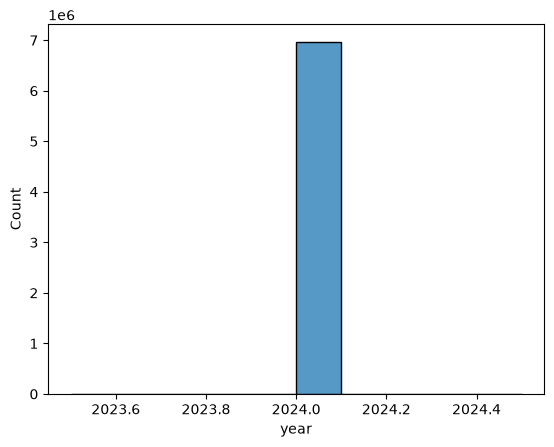

In [63]:
import seaborn as sns

sns.histplot(data=df, x='year', bins=10)

<Axes: xlabel='month', ylabel='Count'>

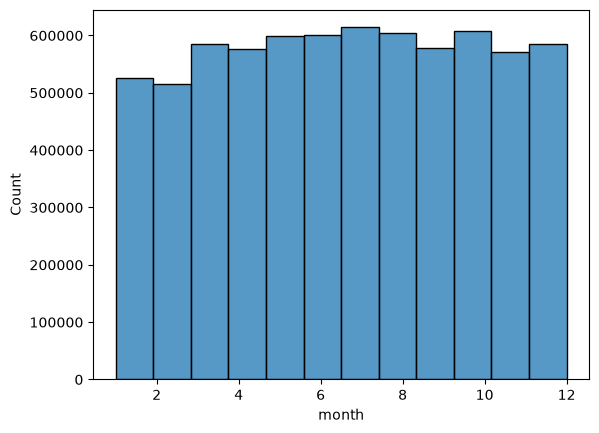

In [64]:
sns.histplot(data=df, x='month', bins=12)

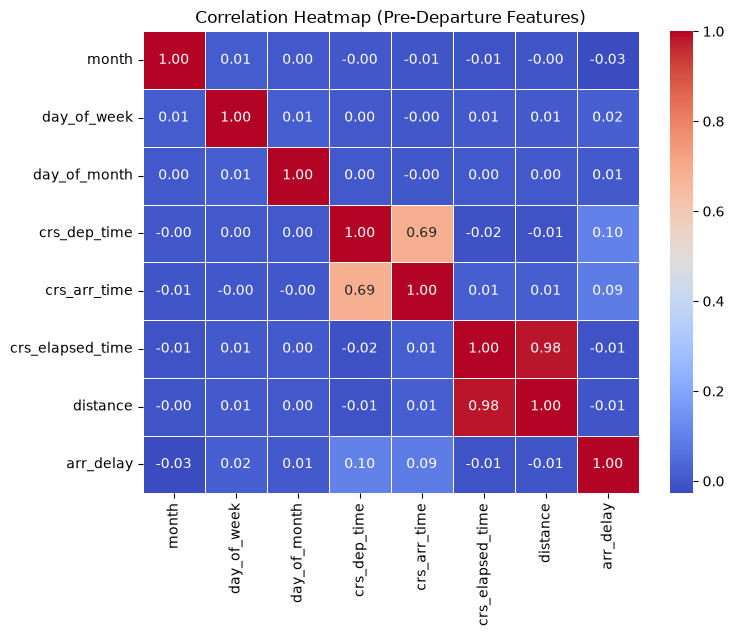

In [65]:
import matplotlib.pyplot as plt

pre_departure_numeric = ['month', 'day_of_week', 'day_of_month', 'crs_dep_time', 
                          'crs_arr_time', 'crs_elapsed_time', 'distance', 'arr_delay']

correlation_matrix = df[pre_departure_numeric].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Pre-Departure Features)")
plt.show()

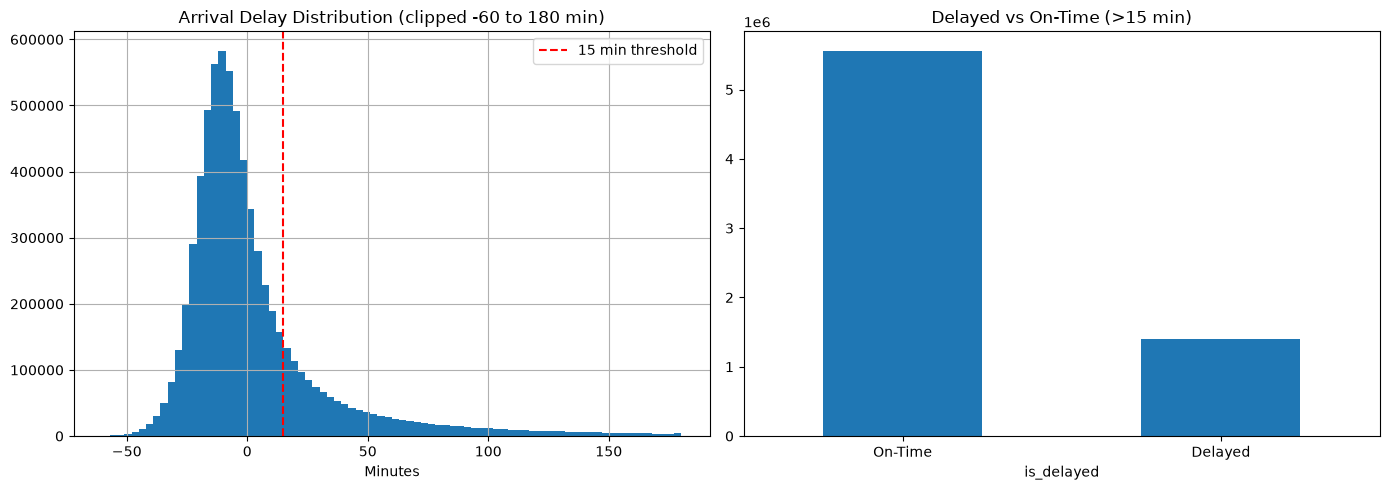

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: zoomed to the bulk of the data
df[df['arr_delay'].between(-60, 180)]['arr_delay'].hist(bins=80, ax=axes[0])
axes[0].axvline(x=15, color='red', linestyle='--', label='15 min threshold')
axes[0].set_title('Arrival Delay Distribution (clipped -60 to 180 min)')
axes[0].set_xlabel('Minutes')
axes[0].legend()

# Right: class balance for binary target
df['is_delayed'].value_counts().plot.bar(ax=axes[1])
axes[1].set_title('Delayed vs On-Time (>15 min)')
axes[1].set_xticklabels(['On-Time', 'Delayed'], rotation=0)

plt.tight_layout()
plt.show()

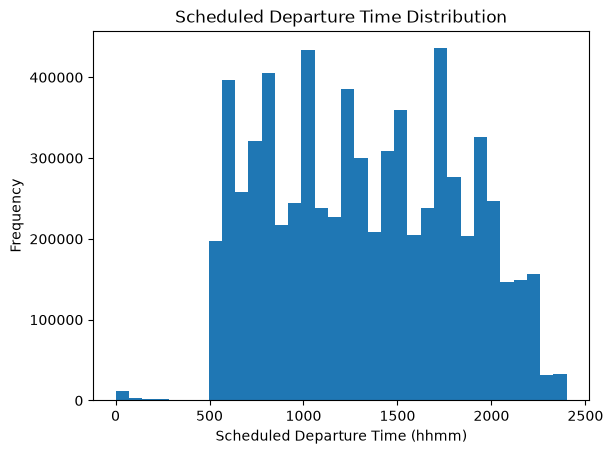

In [67]:
plt.hist(df['crs_dep_time'], bins=34)
plt.title('Scheduled Departure Time Distribution')
plt.xlabel('Scheduled Departure Time (hhmm)')
plt.ylabel('Frequency')
plt.show()

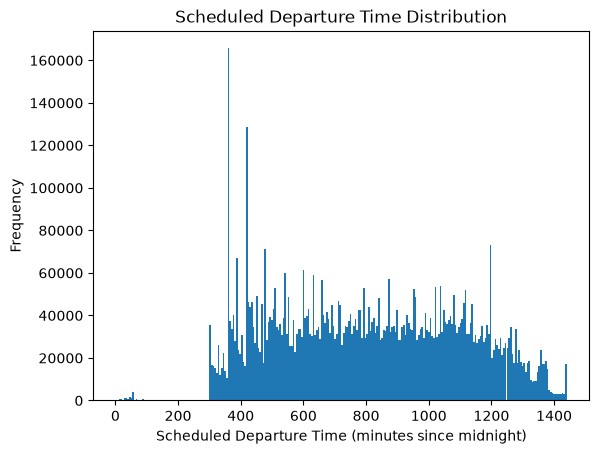

In [68]:
"""

    Engineering into minutes since midnight for easier analysis and modeling.
    Using the Fredman-Diaconis rule to determine the optimal number of bins for the histogram of scheduled departure times in minutes.
"""
df['crs_dep_time_minutes'] = (df['crs_dep_time'] // 100) * 60 + (df['crs_dep_time'] % 100)


plt.hist(df['crs_dep_time_minutes'], bins='fd')
plt.title('Scheduled Departure Time Distribution')
plt.xlabel('Scheduled Departure Time (minutes since midnight)')
plt.ylabel('Frequency')
plt.show()

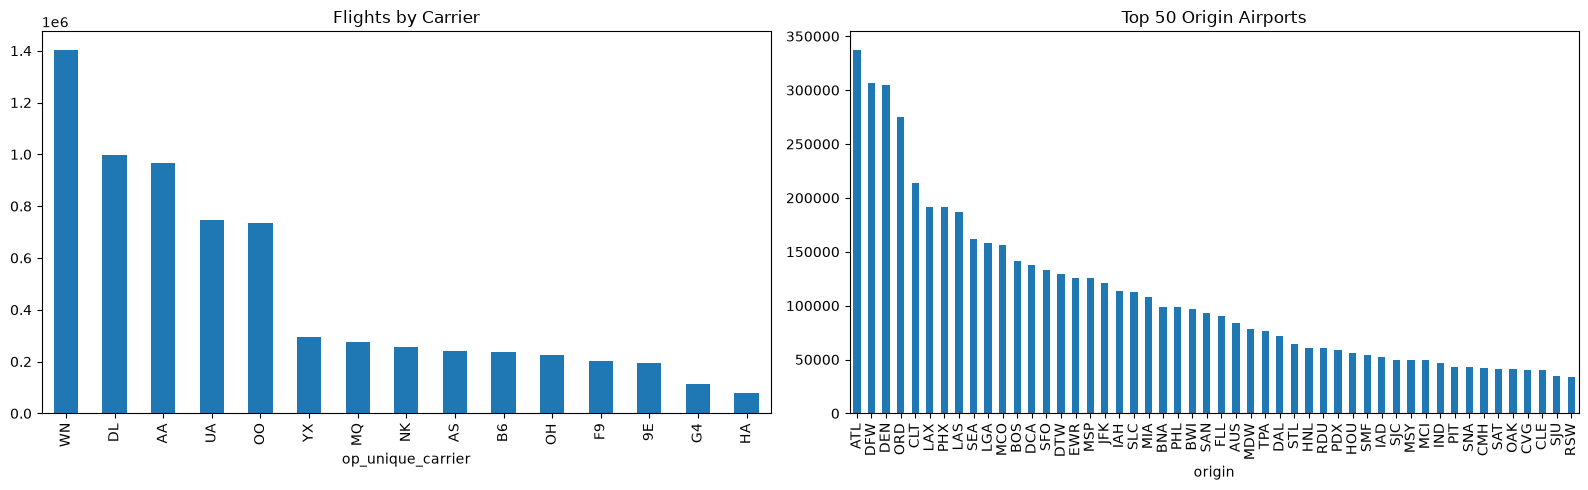

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df['op_unique_carrier'].value_counts().plot.bar(ax=axes[0])
axes[0].set_title('Flights by Carrier')

df['origin'].value_counts().head(50).plot.bar(ax=axes[1])
axes[1].set_title('Top 50 Origin Airports')

plt.tight_layout()
plt.show()

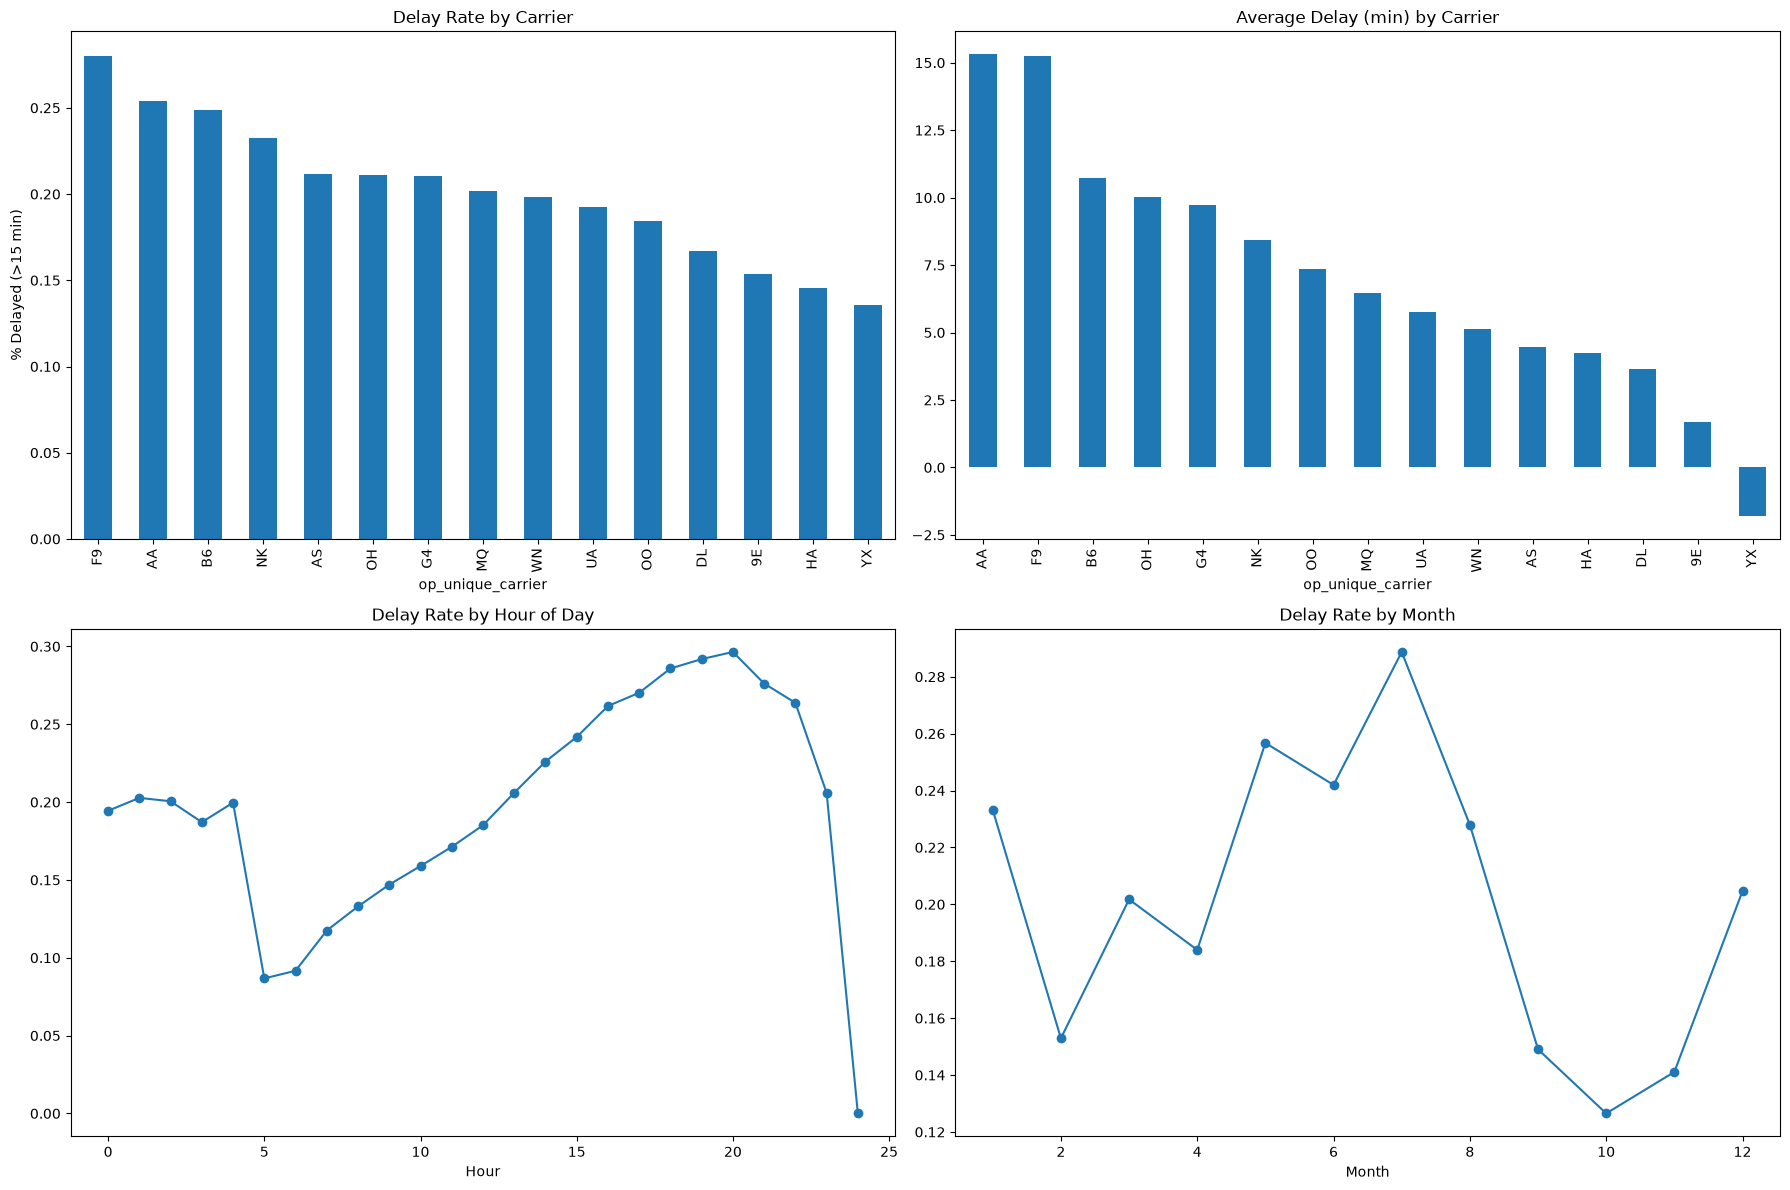

In [70]:
"""
    Does delay rate vary across carriers and airports?
"""

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Delay rate by carrier
carrier_delay = df.groupby('op_unique_carrier')['is_delayed'].mean().sort_values(ascending=False)
carrier_delay.plot.bar(ax=axes[0, 0])
axes[0, 0].set_title('Delay Rate by Carrier')
axes[0, 0].set_ylabel('% Delayed (>15 min)')

# Average delay minutes by carrier
carrier_avg = df.groupby('op_unique_carrier')['arr_delay'].mean().sort_values(ascending=False)
carrier_avg.plot.bar(ax=axes[0, 1])
axes[0, 1].set_title('Average Delay (min) by Carrier')

# Delay rate by hour of day
df['dep_hour'] = df['crs_dep_time_minutes'] // 60
hourly_delay = df.groupby('dep_hour')['is_delayed'].mean()
hourly_delay.plot(ax=axes[1, 0], marker='o')
axes[1, 0].set_title('Delay Rate by Hour of Day')
axes[1, 0].set_xlabel('Hour')

# Delay rate by month
monthly_delay = df.groupby('month')['is_delayed'].mean()
monthly_delay.plot(ax=axes[1, 1], marker='o')
axes[1, 1].set_title('Delay Rate by Month')
axes[1, 1].set_xlabel('Month')

plt.tight_layout()
plt.show()

## Big Picture for delay rates through the day and monthly, as well as per carrier

So starting top left  we dont know the questions like: If F9 has the most delay rate then does it fly in and out of busy airports? when have its flights happened, is it during summer or winter or steady through the year, are its flights long or short? does it fly in cold weather areas(where its more delay prone)? etc. 

Then top right we can see that from both histogram plots the ones with most rate are also the ones with highest amount of delay in minutes.

Then bottom left we see that from midnight to 4 a steady delay rate at around 0.2 then a drop off at 0500 then a steady climb throughout the day peaking at 1900 possibly confirming that the delays are cascaded throughout the day, and then a sharp dropoff at 2000 till 0000, the Sharp drop off at 0000 is beacuse of a data artifact where the data drops off for that hour so we can discount it.

#### EDA so far:
+ dep_hour is a strong feature — clear monotonic relationship with delay
+ month has signal — summer and holiday peaks
+ carrier has signal — 2x difference between best and worst
+ Raw numeric features (distance, elapsed time) have almost no linear signal alone
+ The real predictive power will come from interactions and aggregated features



Text(0, 0.5, '% Delayed (>15 min)')

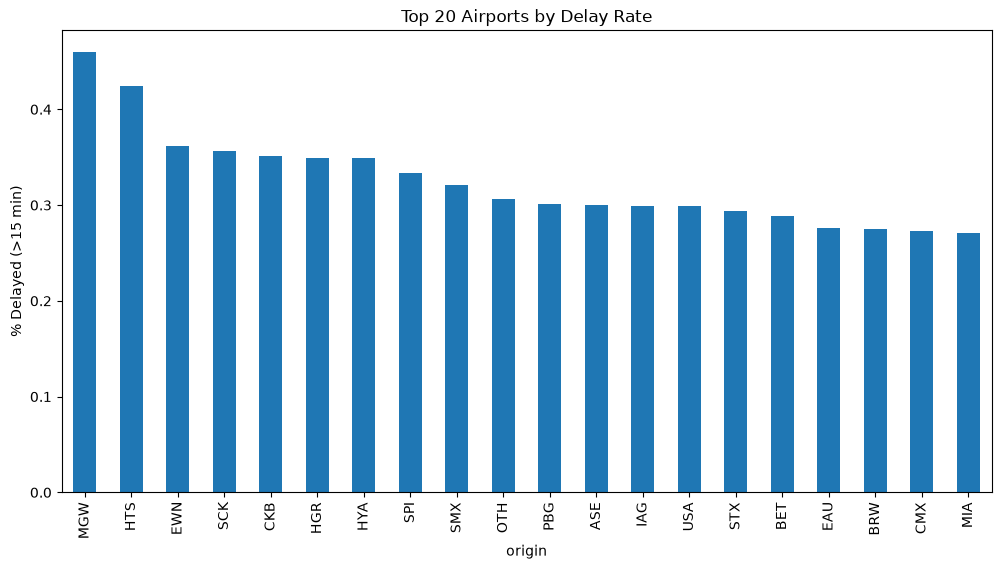

In [71]:
# Top 20 airports by delay rate
top_airports = df.groupby('origin')['is_delayed'].mean().sort_values(ascending=False).head(20)
top_airports.plot.bar(figsize=(12, 6))
plt.title('Top 20 Airports by Delay Rate')
plt.ylabel('% Delayed (>15 min)')

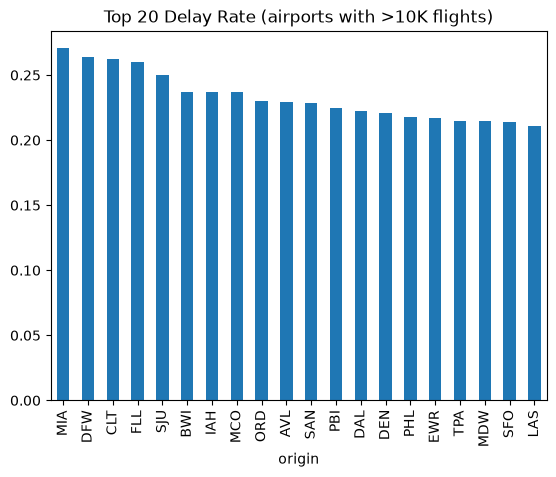

In [72]:
airport_stats = df.groupby('origin').agg(
    delay_rate=('is_delayed', 'mean'),
    flight_count=('is_delayed', 'count')
)
busy = airport_stats[airport_stats['flight_count'] > 10000].sort_values('delay_rate', ascending=False)
busy.head(20)['delay_rate'].plot.bar()
plt.title('Top 20 Delay Rate (airports with >10K flights)')
plt.show()

TARGET ENCODING WITH SMOOTHING
- Replaces a category with its smoothed target mean
- Formula: (n × group_mean + m × global_mean) / (n + m)
- m = smoothing strength (prior weight)
- Part of: empirical Bayes / Bayesian shrinkage
- Use when: high-cardinality categoricals (airports, routes, IDs)
- Danger: target leakage — compute on train only, apply to test
- Same math as: IMDB ratings, baseball stats, A/B testing



In [73]:
def smoothed_target_rate(df, group_col, target_col, smoothing=100):
    """
    Blend group mean with global mean, weighted by sample size.
    Small groups get pulled toward global average.
    """
    global_mean = df[target_col].mean()
    agg = df.groupby(group_col)[target_col].agg(['mean', 'count'])
    smooth = (agg['count'] * agg['mean'] + smoothing * global_mean) / (agg['count'] + smoothing)
    return df[group_col].map(smooth)

df['origin_delay_rate'] = smoothed_target_rate(df, 'origin', 'is_delayed')
df['dest_delay_rate'] = smoothed_target_rate(df, 'dest', 'is_delayed')
df['carrier_delay_rate'] = smoothed_target_rate(df, 'op_unique_carrier', 'is_delayed')

# Route pair
df['route'] = df['origin'] + '_' + df['dest']
df['route_delay_rate'] = smoothed_target_rate(df, 'route', 'is_delayed', smoothing=200)

In [74]:
df.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,dest,dest_city_name,dest_state_nm,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,is_delayed,crs_dep_time_minutes,dep_hour,origin_delay_rate,dest_delay_rate,carrier_delay_rate,route,route_delay_rate
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,DTW,"Detroit, MI",Michigan,1252,1247.0,-5.0,31.0,1318.0,1442.0,7.0,1508,1449.0,-19.0,0,NaN,0,136.0,122.0,84.0,509.0,0,0,0,0,0,0,772,12,0.204279,0.174366,0.153737,JFK_DTW,0.187927
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,CLE,"Cleveland, OH",Ohio,1015,1001.0,-14.0,20.0,1021.0,1249.0,6.0,1325,1255.0,-30.0,0,NaN,0,130.0,114.0,88.0,622.0,0,0,0,0,0,0,615,10,0.183024,0.211487,0.153737,MSP_CLE,0.212363
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,RIC,"Richmond, VA",Virginia,1415,1411.0,-4.0,21.0,1432.0,1533.0,8.0,1601,1541.0,-20.0,0,NaN,0,106.0,90.0,61.0,288.0,0,0,0,0,0,0,855,14,0.204279,0.224530,0.153737,JFK_RIC,0.160904
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,JFK,"New York, NY",New York,1650,1643.0,-7.0,13.0,1656.0,1747.0,12.0,1841,1759.0,-42.0,0,NaN,0,111.0,76.0,51.0,288.0,0,0,0,0,0,0,1010,16,0.187792,0.205974,0.153737,RIC_JFK,0.191228
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,MKE,"Milwaukee, WI",Wisconsin,1015,1010.0,-5.0,21.0,1031.0,1016.0,4.0,1034,1020.0,-14.0,0,NaN,0,79.0,70.0,45.0,237.0,0,0,0,0,0,0,615,10,0.186270,0.212328,0.153737,DTW_MKE,0.192668


<Axes: xlabel='origin_delay_rate', ylabel='dest_delay_rate'>

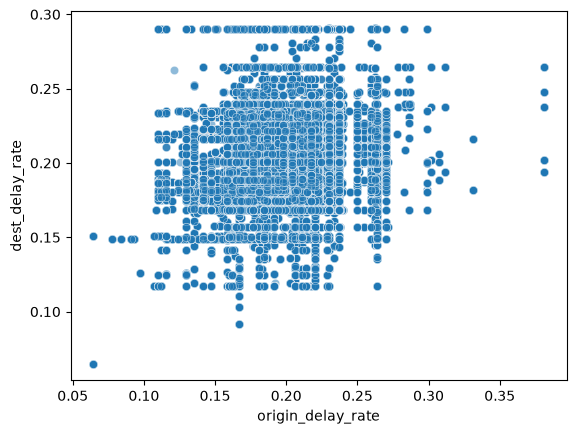

In [75]:
sns.scatterplot(data=df, x='origin_delay_rate', y='dest_delay_rate', alpha=0.5)

Origin and destination delay rates are not strongly correlated with each other. A high-delay origin doesn't necessarily fly to high-delay destinations. That means both features carry independent information

In [76]:
"""
    Quick sanity check for the whole data,
    before continuing with building a directional graph of the airports and their flights.
"""

print(df.describe())
print(df.info())
print(df.isna().sum())

            year         month  ...  carrier_delay_rate  route_delay_rate
count  6965266.0  6.965266e+06  ...        6.965266e+06      6.965266e+06
mean      2024.0  6.597648e+00  ...        2.014837e-01      2.017710e-01
min       2024.0  1.000000e+00  ...        1.358170e-01      7.046467e-02
25%       2024.0  4.000000e+00  ...        1.842898e-01      1.690388e-01
50%       2024.0  7.000000e+00  ...        1.982941e-01      2.007319e-01
75%       2024.0  1.000000e+01  ...        2.117358e-01      2.302637e-01
max       2024.0  1.200000e+01  ...        2.803216e-01      3.871571e-01
std          0.0  3.397294e+00  ...        3.435912e-02      4.575840e-02

[8 rows x 34 columns]
<class 'pandas.DataFrame'>
Index: 6965266 entries, 0 to 7079080
Data columns (total 43 columns):
 #   Column                Dtype         
---  ------                -----         
 0   year                  int64         
 1   month                 int64         
 2   day_of_month          int64         
 3  

### Directed Graph for capturing additional features

What follows below is using the `networkx` library to design a directional graph in order to find out underlying feautres, and analysis using a covariance matrix.

#### Graph

Airports and their flights can be represented as:
Nodes - Airport
Edges - Flights(origin -> dest)
Weight - Flight Count

![USA Airports graph](../images/airport_graph_usa.png)

+ Degree — how many unique routes touch this airport (in + out combined). High degree = hub. This is the simplest centrality measure. Check: ATL should be near the top.

+ In-degree vs out-degree — how many airports fly into this one vs how many it flies out to. For most airports these are similar, but some might be asymmetric (vacation destinations get more inbound than outbound).

+ Betweenness centrality — if you removed this airport, how many shortest paths between other airport pairs would break? High betweenness = bottleneck. An airport can have moderate degree but very high betweenness if it's the only connection between two regions. NetworkX has a function for this — it returns a value between 0 and 1 per node.

+ PageRank — not just "how many connections" but "how important are the airports that connect to you." An airport fed by ATL, ORD, and DFW scores higher than one fed by three tiny regionals, even if both have degree 3. This is literally Google's original algorithm applied to airports instead of web pages. NetworkX has a function for this too.



Added graph features. Columns now: 52
    origin  origin_degree  origin_betweenness  origin_pagerank
394    DFW            372            0.174870         0.046097
590    DEN            360            0.180872         0.045304
16     ATL            314            0.086179         0.043227
442    ORD            326            0.110633         0.037146
19     CLT            264            0.037745         0.026781
399    PHX            221            0.023436         0.022887
835    SEA            184            0.049172         0.022410
395    LAS            263            0.046137         0.021831
413    LAX            219            0.023777         0.021771
1      MSP            242            0.073290         0.019286


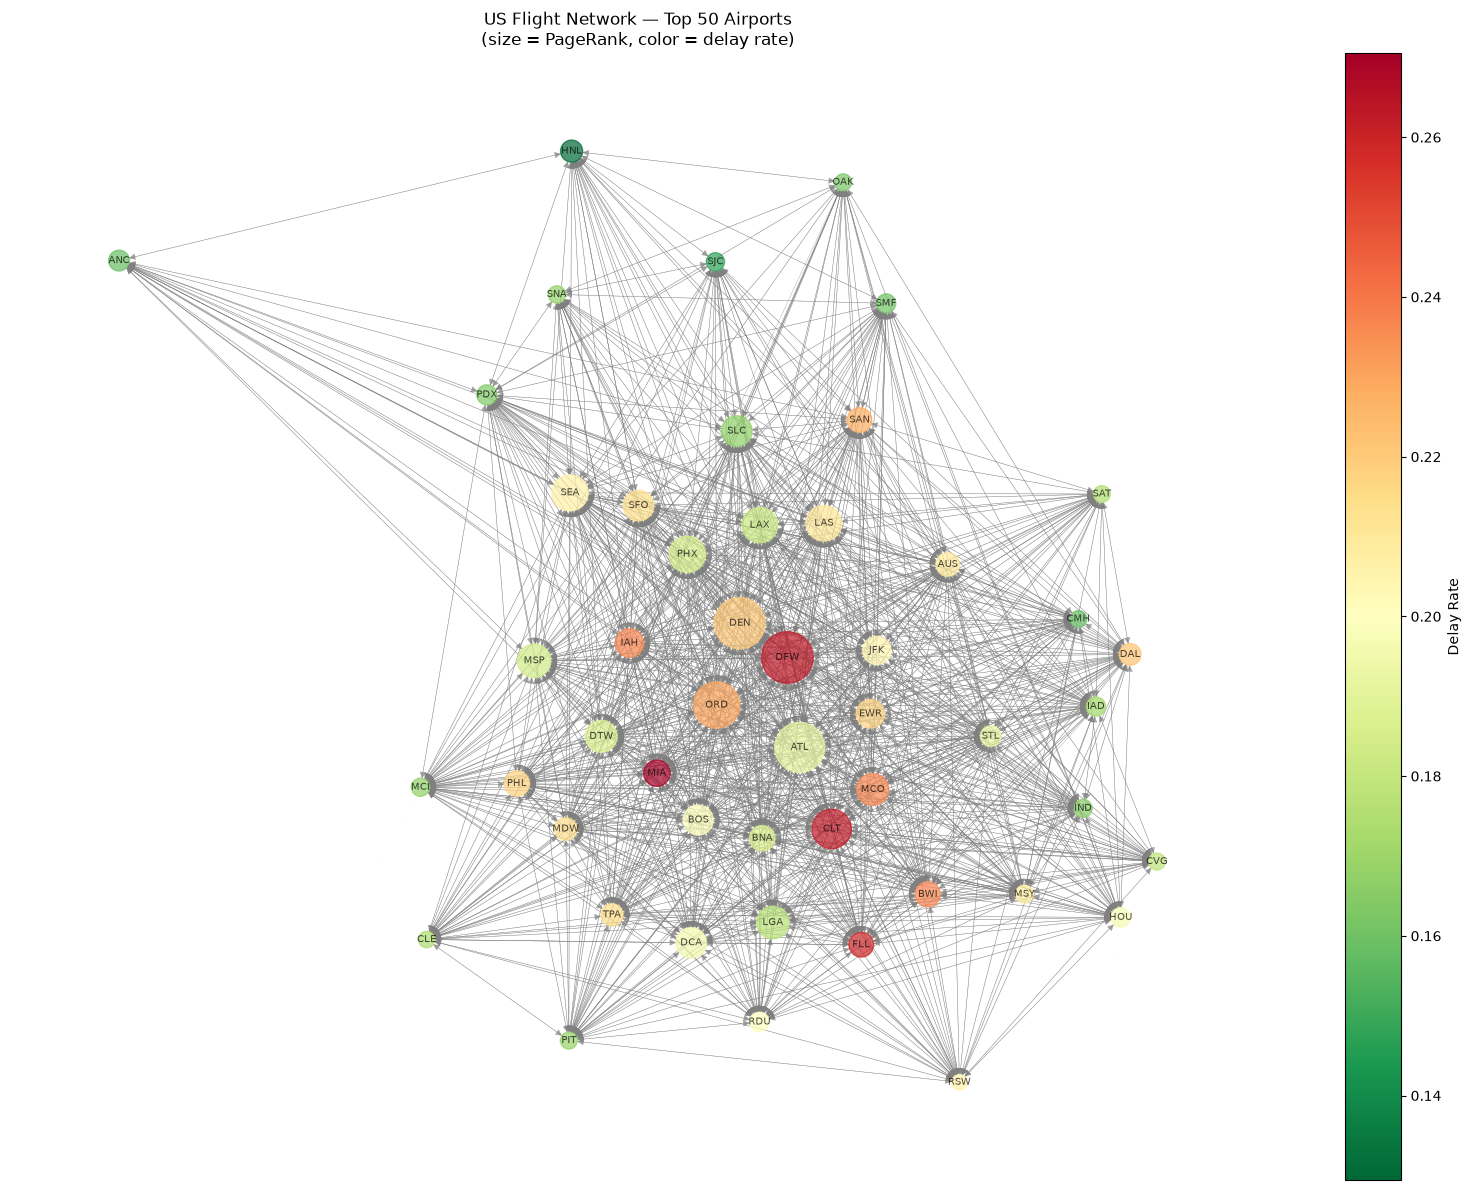

In [ ]:
import networkx as nx

# Build graph
route_counts = df.groupby(['origin', 'dest']).size().reset_index(name='weight')
G = nx.from_pandas_edgelist(route_counts, source='origin', target='dest',
                             edge_attr='weight', create_using=nx.DiGraph())

# Compute metrics
degree = dict(G.degree())
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())
betweenness = nx.betweenness_centrality(G)
pagerank = nx.pagerank(G)
delay_rates = df.groupby('origin')['is_delayed'].mean()

# Map metrics back to the DataFrame
df['origin_degree'] = df['origin'].map(degree)
df['origin_in_degree'] = df['origin'].map(in_degree)
df['origin_betweenness'] = df['origin'].map(betweenness)
df['origin_pagerank'] = df['origin'].map(pagerank)
df['dest_degree'] = df['dest'].map(degree)
df['dest_in_degree'] = df['dest'].map(in_degree)
df['dest_betweenness'] = df['dest'].map(betweenness)
df['dest_pagerank'] = df['dest'].map(pagerank)

origin_counts = df['origin'].value_counts()
df['origin_flight_count'] = df['origin'].map(origin_counts)

print(f"Added graph features. Columns now: {df.shape[1]}")
print(df[['origin', 'origin_degree', 'origin_betweenness', 'origin_pagerank']].drop_duplicates().sort_values('origin_pagerank', ascending=False).head(10))

# Subgraph of top 50 for visualization
top_airports = sorted(pagerank, key=pagerank.get, reverse=True)[:50]
G_sub = G.subgraph(top_airports)

node_sizes = [pagerank.get(n, 0) * 30000 for n in G_sub.nodes()]
node_colors = [delay_rates.get(n, 0.2) for n in G_sub.nodes()]

fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.spring_layout(G_sub, k=2, seed=42)
nx.draw_networkx(G_sub, pos, ax=ax,
                  node_size=node_sizes,
                  node_color=node_colors,
                  cmap=plt.cm.RdYlGn_r,
                  edge_color='gray',
                  alpha=0.7,
                  width=0.3,
                  font_size=7,
                  with_labels=True)

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r,
                            norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Delay Rate')
ax.set_title('US Flight Network — Top 50 Airports\n(size = PageRank, color = delay rate)')
ax.axis('off')
plt.tight_layout()
plt.show()

In [86]:
print(df.columns.tolist())

['year', 'month', 'day_of_month', 'day_of_week', 'fl_date', 'op_unique_carrier', 'op_carrier_fl_num', 'origin', 'origin_city_name', 'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_nm', 'crs_dep_time', 'dep_time', 'dep_delay', 'taxi_out', 'wheels_off', 'wheels_on', 'taxi_in', 'crs_arr_time', 'arr_time', 'arr_delay', 'cancelled', 'cancellation_code', 'diverted', 'crs_elapsed_time', 'actual_elapsed_time', 'air_time', 'distance', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay', 'is_delayed', 'crs_dep_time_minutes', 'dep_hour', 'origin_delay_rate', 'dest_delay_rate', 'carrier_delay_rate', 'route', 'route_delay_rate', 'origin_degree', 'origin_in_degree', 'origin_betweenness', 'origin_pagerank', 'dest_degree', 'dest_in_degree', 'dest_betweenness', 'dest_pagerank', 'origin_flight_count']


In [87]:
df['origin_pagerank_quartile'] = pd.qcut(df['origin_pagerank'], 4, labels=['Q1','Q2','Q3','Q4'])
print(df.groupby('origin_pagerank_quartile')['is_delayed'].mean())

origin_pagerank_quartile
Q1    0.178447
Q2    0.205738
Q3    0.198159
Q4    0.225557
Name: is_delayed, dtype: float64


In [88]:
graph_cols = ['origin_degree', 'origin_betweenness', 'origin_pagerank',
              'dest_degree', 'dest_betweenness', 'dest_pagerank']
print(df[graph_cols].corr().round(2))

                    origin_degree  ...  dest_pagerank
origin_degree                1.00  ...          -0.34
origin_betweenness           0.85  ...          -0.25
origin_pagerank              0.96  ...          -0.31
dest_degree                 -0.36  ...           0.96
dest_betweenness            -0.28  ...           0.91
dest_pagerank               -0.34  ...           1.00

[6 rows x 6 columns]


In [89]:
df.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,dest,dest_city_name,dest_state_nm,crs_dep_time,dep_time,dep_delay,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,is_delayed,crs_dep_time_minutes,dep_hour,origin_delay_rate,dest_delay_rate,carrier_delay_rate,route,route_delay_rate,origin_degree,origin_in_degree,origin_betweenness,origin_pagerank,dest_degree,dest_in_degree,dest_betweenness,dest_pagerank,origin_flight_count,origin_pagerank_quartile
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,DTW,"Detroit, MI",Michigan,1252,1247.0,-5.0,31.0,1318.0,1442.0,7.0,1508,1449.0,-19.0,0,NaN,0,136.0,122.0,84.0,509.0,0,0,0,0,0,0,772,12,0.204279,0.174366,0.153737,JFK_DTW,0.187927,147,73,0.014207,0.013849,203,102,0.046222,0.017475,120770,Q2
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,CLE,"Cleveland, OH",Ohio,1015,1001.0,-14.0,20.0,1021.0,1249.0,6.0,1325,1255.0,-30.0,0,NaN,0,130.0,114.0,88.0,622.0,0,0,0,0,0,0,615,10,0.183024,0.211487,0.153737,MSP_CLE,0.212363,242,121,0.073290,0.019286,84,42,0.000224,0.004666,125365,Q3
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,RIC,"Richmond, VA",Virginia,1415,1411.0,-4.0,21.0,1432.0,1533.0,8.0,1601,1541.0,-20.0,0,NaN,0,106.0,90.0,61.0,288.0,0,0,0,0,0,0,855,14,0.204279,0.224530,0.153737,JFK_RIC,0.160904,147,73,0.014207,0.013849,50,25,0.000501,0.002373,120770,Q2
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,JFK,"New York, NY",New York,1650,1643.0,-7.0,13.0,1656.0,1747.0,12.0,1841,1759.0,-42.0,0,NaN,0,111.0,76.0,51.0,288.0,0,0,0,0,0,0,1010,16,0.187792,0.205974,0.153737,RIC_JFK,0.191228,50,25,0.000501,0.002373,147,73,0.014207,0.013849,17990,Q1
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,MKE,"Milwaukee, WI",Wisconsin,1015,1010.0,-5.0,21.0,1031.0,1016.0,4.0,1034,1020.0,-14.0,0,NaN,0,79.0,70.0,45.0,237.0,0,0,0,0,0,0,615,10,0.186270,0.212328,0.153737,DTW_MKE,0.192668,203,102,0.046222,0.017475,70,35,0.000084,0.003475,129723,Q3


In [94]:
df.to_parquet('../data/df_engineered.parquet', index=False)

<center><h2>Correlation Analysis</h2></center>

After looking at the covariance matrix for our newly engineered features, we will also look at linear and non-linear correlation between features that could be related to `arr_delay`.

Specifically:
+ Pearson Correlation for measuring linear relationships
+ Spearman Correlation for monotonic relationships
+ Mutual Information for any general statistical dependency


<center><h3>Pearson Correlation Coefficient</h3></center>

<p align="center">
  <img src="../images/pearson-correlation.png" alt="Pearson Correlation" />
</p>

Pearson Correlation is useful for finding linear relationships between two features, the output `r` ranges from -1 to 1, where 1 means a strong positive trend, -1 means a strong negative trend, and 0 means no linear trend.

In [95]:
# Pearsons correlation between features and target variable arr_delay

feature_cols = ['month', 'day_of_week', 'day_of_month', 'dep_hour',
                'crs_dep_time_minutes', 'distance',
                'origin_delay_rate', 'dest_delay_rate', 
                'carrier_delay_rate', 'route_delay_rate',
                'origin_pagerank', 'dest_pagerank', 'arr_delay']

df[feature_cols].corr()['arr_delay'].sort_values(ascending=False)

arr_delay               1.000000
crs_dep_time_minutes    0.101665
dep_hour                0.101485
route_delay_rate        0.091319
carrier_delay_rate      0.069953
origin_delay_rate       0.055413
dest_delay_rate         0.046911
origin_pagerank         0.019553
day_of_week             0.017509
day_of_month            0.008368
dest_pagerank           0.005729
distance               -0.005776
month                  -0.027283
Name: arr_delay, dtype: float64

In [96]:
# Spearmans correlation between features and target variable arr_delay

df[feature_cols].corr(method='spearman')['arr_delay'].sort_values(ascending=False)

arr_delay               1.000000
crs_dep_time_minutes    0.165216
dep_hour                0.164813
route_delay_rate        0.135750
carrier_delay_rate      0.082686
origin_delay_rate       0.080250
origin_pagerank         0.059005
dest_delay_rate         0.051464
day_of_week             0.032611
day_of_month            0.007959
distance               -0.012234
dest_pagerank          -0.035275
month                  -0.037012
Name: arr_delay, dtype: float64

In [97]:
from sklearn.feature_selection import mutual_info_regression

sample = df[feature_cols].sample(n=500000, random_state=42)
features = sample.drop(columns='arr_delay')
target = sample['arr_delay']

mi = mutual_info_regression(features, target, random_state=42)
mi_scores = pd.Series(mi, index=features.columns).sort_values(ascending=False)
print(mi_scores)

route_delay_rate        0.043675
distance                0.028020
origin_pagerank         0.026709
origin_delay_rate       0.026283
crs_dep_time_minutes    0.024085
dep_hour                0.021716
carrier_delay_rate      0.020585
dest_delay_rate         0.016477
dest_pagerank           0.014463
month                   0.012473
day_of_month            0.001174
day_of_week             0.001068
dtype: float64


In [98]:
# === COLUMNS TO DROP ===

# 1. Leakage — post-flight data we won't have at prediction time beacuse prediction time happens before the flight takes off
leakage = ['dep_time', 'dep_delay', 'taxi_out', 'wheels_off', 
           'wheels_on', 'taxi_in', 'arr_time', 'actual_elapsed_time', 'air_time',
           'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']

# 2. Redundant features (high correlation with kept features)
redundant = ['fl_date', 'year', 'crs_elapsed_time', 'crs_dep_time', 'crs_arr_time',
             'crs_dep_time_minutes', 'op_carrier_fl_num']

# 3. String columns replaced by encoded versions
encoded_away = ['op_unique_carrier', 'origin', 'dest',
                'origin_city_name', 'origin_state_nm', 
                'dest_city_name', 'dest_state_nm', 'route']

# 4. No longer needed after cleaning
cleanup = ['cancelled', 'cancellation_code', 'diverted']

# 5. Redundant engineered features (high correlation with kept features)
redundant_engineered = ['origin_degree', 'origin_betweenness', 'origin_in_degree',
                        'dest_degree', 'dest_betweenness', 'dest_in_degree',
                        'origin_pagerank_quartile']

all_drops = leakage + redundant + encoded_away + cleanup + redundant_engineered

existing_drops = [c for c in all_drops if c in df.columns]
df_model = df.drop(columns=existing_drops)

print(f"Dropped {len(existing_drops)} columns")
print(f"Remaining: {df_model.shape[1]} columns")
print(f"\nFinal features:")
print(df_model.columns.tolist())

Dropped 39 columns
Remaining: 14 columns

Final features:
['month', 'day_of_month', 'day_of_week', 'arr_delay', 'distance', 'is_delayed', 'dep_hour', 'origin_delay_rate', 'dest_delay_rate', 'carrier_delay_rate', 'route_delay_rate', 'origin_pagerank', 'dest_pagerank', 'origin_flight_count']


In [103]:
df.to_parquet('../data/df_dropped.parquet')

In [104]:
from sklearn.model_selection import train_test_split

# Seperating features and target variables for classification and regression tasks
X = df_model.drop(columns=['arr_delay', 'is_delayed'])
y_cls = df_model['is_delayed']
y_reg = df_model['arr_delay']

# Time splitting data: Train on flights from Jan to Oct, test on Nov and Dec
train_mask = df_model['month'] <= 10
test_mask = df_model['month'] > 10

X_train, X_test = X[train_mask], X[test_mask]
y_train_reg, y_test_reg = y_reg[train_mask], y_reg[test_mask]
y_train_cls, y_test_cls = y_cls[train_mask], y_cls[test_mask]

print(f"Train: {X_train.shape[0]:,} rows (Jan-Oct)")
print(f"Test:  {X_test.shape[0]:,} rows (Nov-Dec)")
print(f"Split: {X_train.shape[0]/len(X)*100:.0f}% / {X_test.shape[0]/len(X)*100:.0f}%")
print(f"\nTrain delay rate: {y_train_cls.mean():.3f}")
print(f"Test delay rate:  {y_test_cls.mean():.3f}")

Train: 5,808,501 rows (Jan-Oct)
Test:  1,156,765 rows (Nov-Dec)
Split: 83% / 17%

Train delay rate: 0.207
Test delay rate:  0.173


In [105]:
from sklearn.metrics import (accuracy_score, 
                             f1_score, 
                             roc_auc_score,
                              mean_absolute_error, 
                              mean_squared_error, 
                              r2_score)
import numpy as np

# === BASELINE: always predict "not delayed" ===
baseline_preds = np.zeros(len(y_test_cls))
print("=== Baseline (predict majority class) ===")
print(f"Accuracy: {accuracy_score(y_test_cls, baseline_preds):.4f}")
print(f"F1:       {f1_score(y_test_cls, baseline_preds):.4f}")

# === BASELINE: always predict mean delay ===
mean_delay = y_train_reg.mean()
baseline_reg = np.full(len(y_test_reg), mean_delay)
print(f"\n=== Baseline (predict mean delay) ===")
print(f"MAE: {mean_absolute_error(y_test_reg, baseline_reg):.2f} min")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, baseline_reg)):.2f} min")

=== Baseline (predict majority class) ===
Accuracy: 0.8268
F1:       0.0000

=== Baseline (predict mean delay) ===
MAE: 26.30 min
RMSE: 52.98 min


In [107]:
from xgboost import XGBClassifier, XGBRegressor

# === CLASSIFICATION ===
clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=len(y_train_cls[y_train_cls==0]) / len(y_train_cls[y_train_cls==1]),
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train_cls)
y_pred_cls = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

print("=== XGBoost Classification ===")
print(f"Accuracy:  {accuracy_score(y_test_cls, y_pred_cls):.4f}")
print(f"F1:        {f1_score(y_test_cls, y_pred_cls):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_cls, y_pred_proba):.4f}")

# === REGRESSION ===
reg = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

reg.fit(X_train, y_train_reg)
y_pred_reg = reg.predict(X_test)

print(f"\n=== XGBoost Regression ===")
print(f"MAE:  {mean_absolute_error(y_test_reg, y_pred_reg):.2f} min")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)):.2f} min")
print(f"R²:   {r2_score(y_test_reg, y_pred_reg):.4f}")

=== XGBoost Classification ===
Accuracy:  0.7690
F1:        0.2442
ROC-AUC:   0.6233

=== XGBoost Regression ===
MAE:  22.48 min
RMSE: 52.63 min
R²:   0.0065


In [ ]:
"""
    To load later:
    
    
    with open('./models/xgb_classifier.pkl', 'rb') as f:
    clf = pickle.load(f)
    
    
    
"""


import pickle
import os

os.makedirs('../models', exist_ok=True)

with open('./models/xgb_classifier.pkl', 'wb') as f:
    pickle.dump(clf, f)

with open('../models/xgb_regressor.pkl', 'wb') as f:
    pickle.dump(reg, f)

print("Models saved to ./models/")

Models saved to ./models/


In [109]:
import pandas as pd

# Feature importances
fi = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("=== Classification Feature Importance ===")
print(fi)
print()

fi_reg = pd.Series(reg.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("=== Regression Feature Importance ===")
print(fi_reg)

=== Classification Feature Importance ===
dep_hour               0.301671
route_delay_rate       0.245306
month                  0.098488
carrier_delay_rate     0.075716
day_of_month           0.059787
day_of_week            0.053999
dest_delay_rate        0.030976
dest_pagerank          0.029116
origin_flight_count    0.028439
origin_pagerank        0.028140
origin_delay_rate      0.027035
distance               0.021326
dtype: float32

=== Regression Feature Importance ===
route_delay_rate       0.185493
dep_hour               0.177481
month                  0.134040
carrier_delay_rate     0.124524
day_of_month           0.099815
day_of_week            0.066417
origin_pagerank        0.040947
dest_pagerank          0.039234
dest_delay_rate        0.038348
origin_flight_count    0.032582
origin_delay_rate      0.032545
distance               0.028574
dtype: float32
